## 1. Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(42)

## 2. Gerando dados simulados de vendas de veículos

Vamos simular clientes com:

- renda anual
- idade
- preço do veículo comprado
- número de parcelas

In [2]:
n = 300

renda = np.random.normal(loc=50000, scale=15000, size=n)
idade = np.random.randint(20, 70, size=n)

# Perfis de compra diferentes
preco_veiculo = (
    renda * np.random.uniform(0.3, 0.7, size=n)
    + np.random.normal(0, 5000, size=n)
)

parcelas = np.clip(
    np.random.normal(loc=48, scale=12, size=n).astype(int),
    12, 72
)

dados = pd.DataFrame({
    "Renda_Anual": renda,
    "Idade": idade,
    "Preco_Veiculo": preco_veiculo,
    "Parcelas": parcelas
})

dados.head()

,Renda_Anual,Idade,Preco_Veiculo,Parcelas
0,57450.712295,55,40250.370386,37
1,47926.035482,29,23169.777816,48
2,59715.328072,56,28269.590123,44
3,72845.447846,28,35043.488310,46
4,46487.699379,43,16658.429108,45


## 3. Exploração inicial dos dados

In [3]:
print(dados.describe())

         Renda_Anual       Idade  Preco_Veiculo    Parcelas
count     300.000000  300.000000     300.000000  300.000000
mean    49916.771614   44.503333   24050.214460   47.753333
std     14762.905335   14.264463   10162.513442   11.548899
min      1380.989899   20.000000   -2996.941887   21.000000
25%     39751.310900   32.000000   16627.718111   39.000000
50%     50888.291963   44.000000   23364.772440   48.000000
75%     59399.865820   56.000000   30525.628025   56.000000
max    107790.972360   69.000000   57399.398545   72.000000


## 4. Visualização dos padrões de compra
Relação entre renda e preço do veículo.

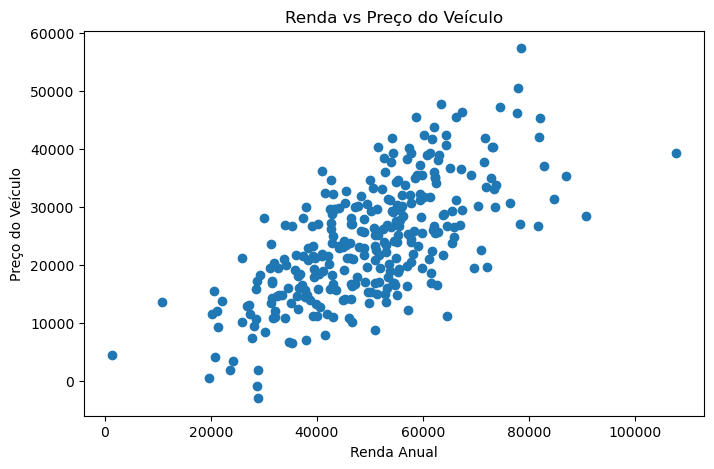

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(dados["Renda_Anual"], dados["Preco_Veiculo"])
plt.xlabel("Renda Anual")
plt.ylabel("Preço do Veículo")
plt.title("Renda vs Preço do Veículo")
plt.show()

## 5. Agrupamento de clientes (Clustering)

Vamos descobrir perfis de compradores automaticamente.

In [5]:
features = dados[["Renda_Anual", "Preco_Veiculo", "Parcelas"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
dados["Grupo_Cliente"] = kmeans.fit_predict(X_scaled)

dados.head()

/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,Renda_Anual,Idade,Preco_Veiculo,Parcelas,Grupo_Cliente
0,57450.712295,55,40250.370386,37,1
1,47926.035482,29,23169.777816,48,0
2,59715.328072,56,28269.590123,44,1
3,72845.447846,28,35043.488310,46,1
4,46487.699379,43,16658.429108,45,0


## 6. Visualizando os grupos encontrados

In [ ]:
plt.figure(figsize=(8,5))

for grupo in dados["Grupo_Cliente"].unique():
    subset = dados[dados["Grupo_Cliente"] == grupo]
    plt.scatter(subset["Renda_Anual"], subset["Preco_Veiculo"], label=f"Grupo {grupo}")

plt.xlabel("Renda Anual")
plt.ylabel("Preço do Veículo")
plt.title("Segmentação de Clientes por Perfil de Compra")
plt.legend()
plt.show()

## 7. Interpretação dos grupos

In [ ]:
dados.groupby("Grupo_Cliente").mean()

### Para pensar:

- qual grupo compra veículos mais caros?
- quem parcela mais?
- existe relação entre renda e financiamento?